# Results Visualisation

Figures for the constructed set, ordered so the finding is visible first. The
predicted action drawn on the stimulus, then the same result as rates and as
signed actions, then the instrument check and the controls. Inventory, resolution,
and a stimulus gallery follow as methods. Definitions and statistics match
Notebook 06, which is the authority for every number shown here. This notebook
imports the same functions from `analysis.py` so the two cannot disagree.

The model is never loaded. Inputs are the prediction log and the frozen
constructed set. Unaltered Bridge rows in the log are held back, matching
Notebook 06. Figures are written under the Drive cache as PNGs for reporting.

Every comparison is read on the axis its spatial term contrasts, and on the
continuous expected-bin readout rather than the quantised action, for the reasons
set out in Notebook 06. In this frozen set every original instruction names
`left` and the swapped instruction names `right`, so the two colours are those
terms rather than role letters.


## 1. Mount Drive

In [39]:
from google.colab import drive
drive.mount('/content/drive')
import os
PRED_CSV = '/content/drive/MyDrive/openvla_cache/v2/probe_predictions.csv'
CACHE_DIR = '/content/drive/MyDrive/openvla_cache/v2/bridge'
CONSTRUCTED_DIR = '/content/drive/MyDrive/openvla_cache/v2/constructed'
MANIFEST_CSV = os.path.join(CACHE_DIR, 'manifest.csv')
FIGS_DIR = '/content/drive/MyDrive/openvla_cache/v2/results_figs'
os.makedirs(FIGS_DIR, exist_ok=True)
print('predictions ->', PRED_CSV)
print('constructed ->', CONSTRUCTED_DIR)
print('figures     ->', FIGS_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
predictions -> /content/drive/MyDrive/openvla_cache/v2/probe_predictions.csv
constructed -> /content/drive/MyDrive/openvla_cache/v2/constructed
figures     -> /content/drive/MyDrive/openvla_cache/v2/results_figs


## 2. Import the code

Clones the project code from GitHub into the runtime and imports the shared
analysis functions, so the figures always match the pushed commit and the
statistics reported in Notebook 06.

In [40]:
import sys, os, importlib, subprocess

REPO_URL = 'https://github.com/LewisTL/ECS8056.git'
BRANCH = 'master'
REPO_DIR = '/content/ECS8056'

def sync_repo():
    """Clone or hard-refresh the repository so it matches origin/BRANCH."""
    token = os.environ.get('GITHUB_TOKEN', '')
    url = REPO_URL.replace('https://', f'https://{token}@') if token else REPO_URL
    if os.path.isdir(os.path.join(REPO_DIR, '.git')):
        subprocess.run(['git', '-C', REPO_DIR, 'remote', 'set-url', 'origin', url],
                       check=True)
        subprocess.run(['git', '-C', REPO_DIR, 'fetch', '--quiet', '--depth', '1',
                        'origin', BRANCH], check=True)
        subprocess.run(['git', '-C', REPO_DIR, 'reset', '--hard', '--quiet',
                        f'origin/{BRANCH}'], check=True)
    else:
        subprocess.run(['git', 'clone', '--quiet', '--depth', '1', '--branch',
                        BRANCH, url, REPO_DIR], check=True)
    return subprocess.run(['git', '-C', REPO_DIR, 'rev-parse', '--short', 'HEAD'],
                          capture_output=True, text=True).stdout.strip()


commit = sync_repo()
module_dir = REPO_DIR
if module_dir not in sys.path:
    sys.path.insert(0, module_dir)
for _m in ('action_bins', 'prediction_log', 'data', 'controls', 'compose_scenes', 'export_pairs', 'analysis',):
    sys.modules.pop(_m, None)
importlib.invalidate_caches()

import analysis
from analysis import (axis_value, wilcoxon_paired, resolution_report,
                      mirror_check, lexical_check, term_effect,
                      congruence_test, absolute_congruence, same_side_test,
                      CONTINUOUS_COLS)
from export_pairs import load_inputs, build_pairs
from compose_scenes import (evaluation_scenes, load_constructed_manifest,
                            IMAGE_X_TO_LATERAL_SIGN, GRIPPER_SOURCE_DETECTED,
                            action_image_delta, gripper_image_xy)
from data import AXIS_INDEX
print(f'imported project modules from {module_dir} @ {commit}')

imported project modules from /content/ECS8056 @ 41be4c2


## 3. Load and prepare

`load_inputs` validates that the prediction log carries the required probe
columns and fails loudly if any are missing. Rows without a continuous readout
were migrated from an earlier log and are held back from the continuous figures.
Unaltered Bridge rows are counted, then held back, so every figure below is the
constructed set.

The lateral bin width is the value printed by Notebook 05 from the loaded
model, not a test-fixture constant.


In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Lateral entry of describe_action_space()['bin_width'], printed by Notebook 05.
BIN_WIDTH = 0.000225

COLOURS = {
    'constructed': '#4C72B0',
    'opposite': '#4C72B0',
    'same_side_left': '#55A868',
    'same_side_right': '#8172B3',
    'argmax': '#937860',
    'continuous': '#4C72B0',
}
ROLE_COLOURS = {'a': '#4C72B0', 'b': '#C44E52'}
ROLE_LABELS = {'a': 'left', 'b': 'right'}
CONFIG_ORDER = ('same_side_left', 'opposite', 'same_side_right')
CONFIG_LABELS = {
    'same_side_left': 'both on the left',
    'opposite': 'opposite sides',
    'same_side_right': 'both on the right',
}
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

preds, manifest = load_inputs(PRED_CSV, MANIFEST_CSV)
n_bridge = int((preds['scene_source'] == 'bridge').sum())
coverage = preds[CONTINUOUS_COLS].notna().all(axis=1)
usable = preds[coverage & (preds['scene_source'] == 'constructed')].copy()
usable['value'] = axis_value(usable)
built = usable
print(f'{len(preds)} predictions in the log | {n_bridge} unaltered Bridge rows held back')
print(f'constructed predictions used: {len(usable)} | continuous readout on '
      f'{int(coverage.sum())} of {len(preds)} ({coverage.mean():.1%})')


def save(fig, name):
    out = os.path.join(FIGS_DIR, name)
    fig.savefig(out, dpi=150, bbox_inches='tight')
    print('wrote', out)
    return out


def paired_difference(frame, condition='baseline', continuous=True):
    """Signed A minus B difference per scene on that scene's own axis."""
    sub = frame[frame['condition'] == condition].copy()
    if sub.empty:
        return pd.DataFrame(columns=['scene_id', 'diff'])
    sub['value'] = axis_value(sub, continuous=continuous)
    wide = sub.pivot_table(index='scene_id', columns='role', values='value')
    if not {'a', 'b'} <= set(wide.columns):
        return pd.DataFrame(columns=['scene_id', 'diff'])
    wide = wide.dropna(subset=['a', 'b'])
    return pd.DataFrame({'scene_id': wide.index,
                         'diff': (wide['a'] - wide['b']).to_numpy()})


def baseline_pairs(frame, condition='baseline'):
    """One row per scene: lateral values for left and right, plus configuration."""
    sub = frame[frame['condition'] == condition].copy()
    if sub.empty:
        return pd.DataFrame(columns=['a', 'b', 'configuration'])
    sub['value'] = axis_value(sub)
    wide = sub.pivot_table(index='scene_id', columns='role', values='value')
    if not {'a', 'b'} <= set(wide.columns):
        return pd.DataFrame(columns=['a', 'b', 'configuration'])
    meta = (frame.drop_duplicates('scene_id')
            .set_index('scene_id')['configuration'])
    out = wide[['a', 'b']].join(meta)
    return out.dropna(subset=['a', 'b'])


/content/drive/MyDrive/openvla_cache/v2/probe_predictions.csv
  67 columns, 10196 rows, consistent
10196 predictions in the log | 8276 unaltered Bridge rows held back
constructed predictions used: 1920 | continuous readout on 10196 of 10196 (100.0%)


/content/ECS8056/export_pairs.py:158: DtypeWarning: Columns (56) have mixed types. Specify dtype option on import or set low_memory=False.
  preds = pd.read_csv(pred_path)


## 4. Predicted directions over the scene

The result at the level of individual stimuli. Nine constructed scenes, three
per arrangement, each with the predicted translation for both instructions drawn
as an arrow from the detected gripper centre, and a ring marking the instance that
instruction names.

A grounded response reaches toward its own ring, and the side that ring occupies
follows the arrangement. A word-to-direction response sends `left` one way and
`right` the other on every scene. An image-left prior sends both arrows the same
way regardless of the term and of which side the objects occupy.

The arrow is the full predicted translation, not the lateral component alone.
Lateral maps to image x, depth recedes down the frame (the arm enters from the
top, so away from the robot is toward the bottom), and vertical points up the
frame. Both arrows share the detected gripper centre as their origin. Scenes
whose start position fell back to the image centre are excluded, because that
origin is not a localisation of the arm.

Arrow length is the projected magnitude on one shared scale across all nine
panels, so lengths are comparable between panels. The circle around the origin
is one action bin in radius on that same scale: an arrow that does not leave it
is below the resolution of the emitted action, whatever direction it appears to
take.

Three scenes are drawn at random from the eligible pool of each arrangement, so
the figure is not pinned to the first or evenly spaced IDs. The draw uses a
fixed seed (`SAMPLE_SEED` in the cell) so a re-run of the notebook reproduces
the same panels unless that seed is changed.


random sample of up to 3 eligible scenes per arrangement (seed=0)
  both on the left: 3 of 36
  opposite sides: 3 of 67
  both on the right: 3 of 31
excluded 106 scenes whose start position fell back to the image centre
wrote /content/drive/MyDrive/openvla_cache/v2/results_figs/01_predicted_directions.png


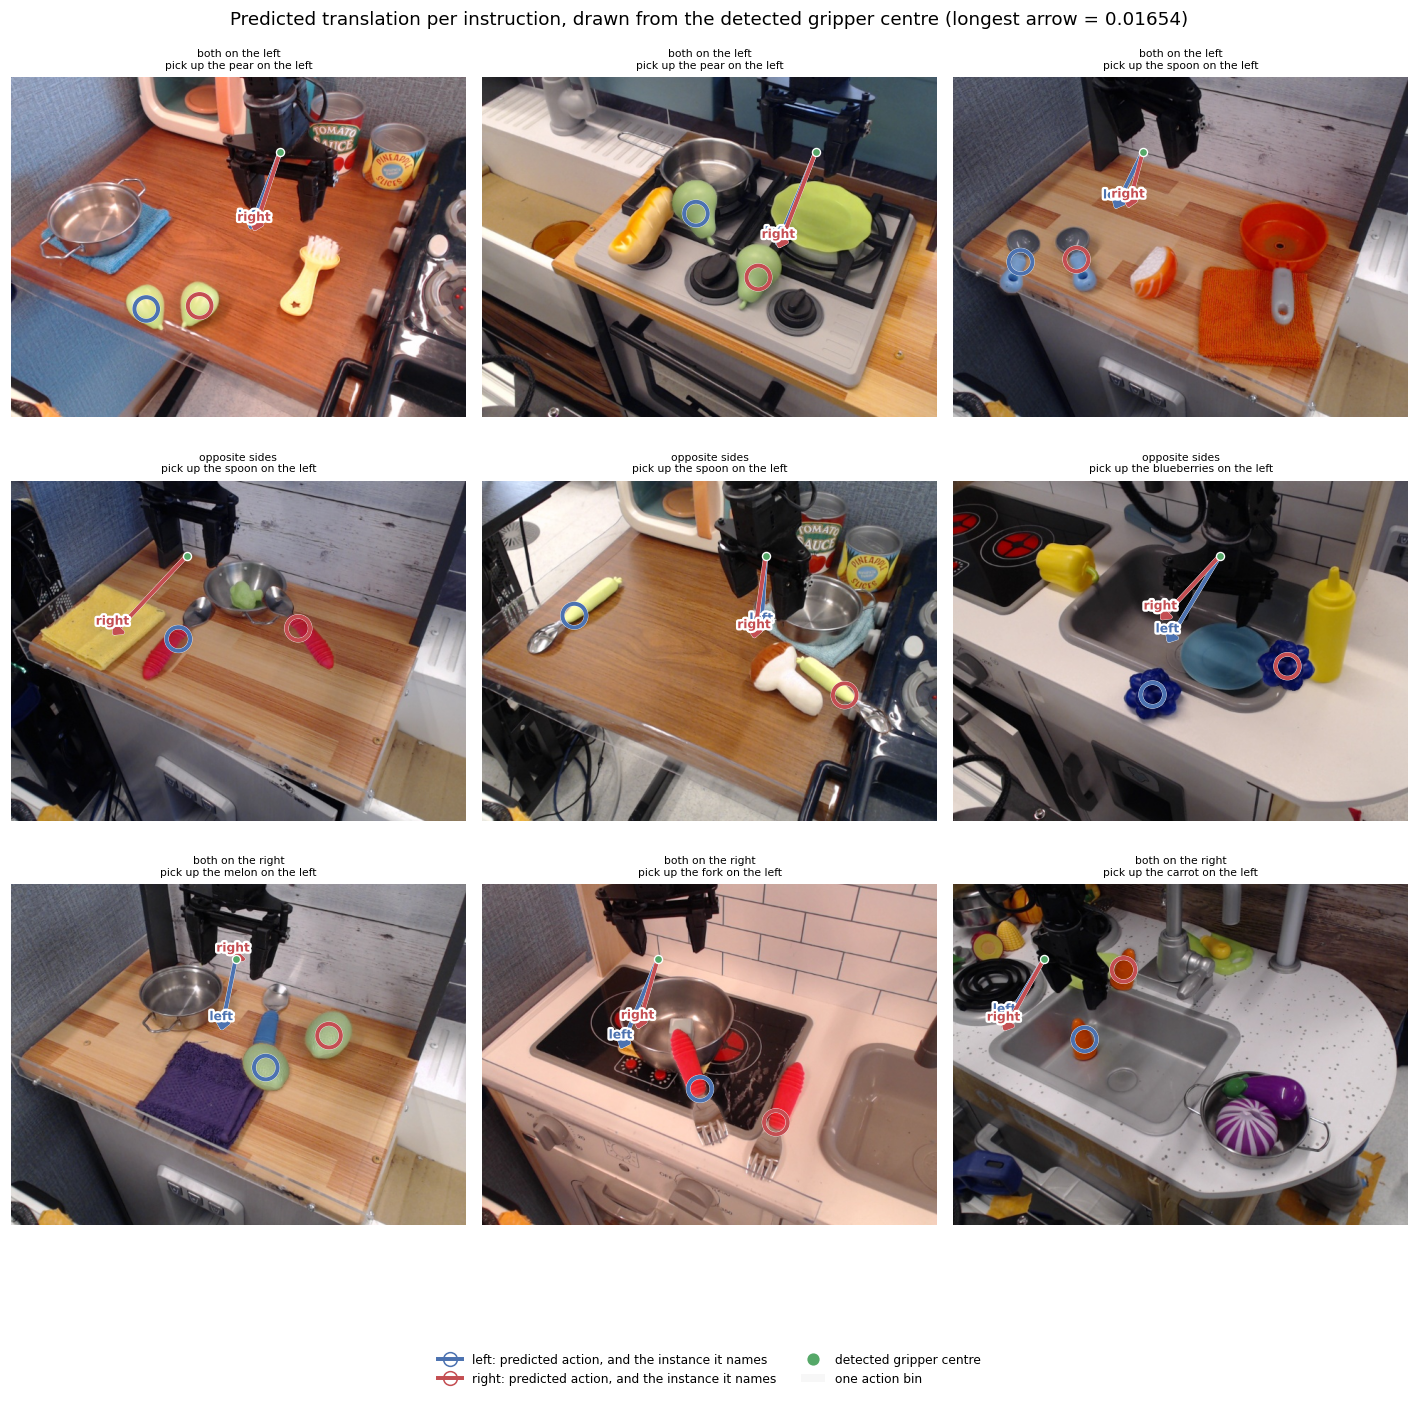

In [53]:
from matplotlib import patheffects
from matplotlib.lines import Line2D
from matplotlib.patches import Circle, Patch
from PIL import Image

PER_CONFIGURATION = 3
SAMPLE_SEED = 0
ARROW_SPAN = 0.28
STROKE = [patheffects.withStroke(linewidth=3.0, foreground='white')]

geometry = {s['construct_id']: s for s in evaluation_scenes(CONSTRUCTED_DIR)}
baseline = built[built['condition'] == 'baseline']
translation = (baseline.pivot_table(index='scene_id', columns='role',
                                    values=['c0', 'c1', 'c2'])
               if not baseline.empty else pd.DataFrame())

have_ab = (
    not translation.empty
    and {'a', 'b'} <= set(translation.columns.get_level_values(-1))
    and geometry
)
if not have_ab:
    print('needs baseline predictions on the frozen constructed set; run '
          'Notebooks 03 and 05 first')
else:
    complete = (translation['c0'][['a', 'b']].notna().all(axis=1)
                & translation['c1'][['a', 'b']].notna().all(axis=1)
                & translation['c2'][['a', 'b']].notna().all(axis=1))
    translation = translation.loc[complete]
    configuration_of = (built.drop_duplicates('scene_id')
                        .set_index('scene_id')['configuration'])

    rng = np.random.default_rng(SAMPLE_SEED)
    chosen = []
    n_fallback = 0
    print(f'random sample of up to {PER_CONFIGURATION} eligible scenes per '
          f'arrangement (seed={SAMPLE_SEED})')
    for configuration in CONFIG_ORDER:
        available = []
        for scene_id in translation.index:
            scene = geometry.get(scene_id)
            if scene is None or configuration_of.get(scene_id) != configuration:
                continue
            if scene.get('gripper_source') != GRIPPER_SOURCE_DETECTED:
                n_fallback += 1
                continue
            available.append(scene_id)
        n = min(PER_CONFIGURATION, len(available))
        if n:
            drawn = rng.choice(available, size=n, replace=False)
            chosen += list(drawn)
            print(f'  {CONFIG_LABELS[configuration]}: {n} of {len(available)}')
    if n_fallback:
        print(f'excluded {n_fallback} scenes whose start position fell back '
              'to the image centre')

    if not chosen:
        print('no constructed scene with a detected gripper has both '
              'instructions logged under baseline')
    else:
        def projected_length(scene_id, role):
            c0 = float(translation.loc[scene_id, ('c0', role)])
            c1 = float(translation.loc[scene_id, ('c1', role)])
            c2 = float(translation.loc[scene_id, ('c2', role)])
            px, py = action_image_delta(c0, c1, c2, scale=1.0)
            return float(np.hypot(px, py))

        longest = max(projected_length(scene_id, role)
                      for scene_id in chosen for role in ('a', 'b'))
        mean_width = float(np.mean([float(geometry[i]['image_width'])
                                    for i in chosen]))
        scale = ARROW_SPAN * mean_width / max(longest, BIN_WIDTH)

        rows = int(np.ceil(len(chosen) / 3))
        fig, axes = plt.subplots(rows, 3, figsize=(13, 4.2 * rows))
        axes = np.atleast_1d(axes).ravel()
        for ax, scene_id in zip(axes, chosen):
            scene = geometry[scene_id]
            image = Image.open(os.path.join(CONSTRUCTED_DIR, scene['image_path']))
            ax.imshow(image)
            x_gripper, y_gripper = gripper_image_xy(scene, image.height)
            ax.add_patch(Circle(
                (x_gripper, y_gripper), BIN_WIDTH * scale,
                facecolor='#F2F2F2', edgecolor='none', alpha=0.55, zorder=2))
            ax.scatter([x_gripper], [y_gripper], marker='o', s=28,
                       color='#55A868', edgecolors='white', linewidths=0.9,
                       zorder=4)
            x_source, x_pasted = float(scene['x_source']), float(scene['x_pasted'])
            y_source, y_shift = float(scene['y_source']), float(scene['y_shift_px'])
            for role in ('a', 'b'):
                colour = ROLE_COLOURS[role]
                x_target = float(scene[f'x_target_{role}'])
                is_source = abs(x_target - x_source) <= abs(x_target - x_pasted)
                y_target = y_source if is_source else y_source + y_shift
                c0 = float(translation.loc[scene_id, ('c0', role)])
                c1 = float(translation.loc[scene_id, ('c1', role)])
                c2 = float(translation.loc[scene_id, ('c2', role)])
                dx, dy = action_image_delta(c0, c1, c2, scale=scale)
                ax.annotate('', xy=(x_gripper + dx, y_gripper + dy),
                            xytext=(x_gripper, y_gripper),
                            arrowprops=dict(arrowstyle='-|>,head_width=0.35',
                                            lw=2.6, shrinkA=0, shrinkB=0,
                                            color=colour, path_effects=STROKE))
                ax.scatter([x_target], [y_target], marker='o', s=240,
                           facecolors='none', linewidths=2.6, edgecolors=colour,
                           path_effects=STROKE, zorder=3)
                ax.annotate(ROLE_LABELS[role], xy=(x_gripper + dx, y_gripper + dy),
                            fontsize=8, color=colour, weight='bold',
                            ha='center', va='bottom', xytext=(0, 5),
                            textcoords='offset points', path_effects=STROKE)
            ax.set_title(f"{CONFIG_LABELS.get(scene['configuration'], scene['configuration'])}"
                         f"\n{scene['instr_a'][:52]}", fontsize=7)
            ax.set_xlim(0, image.width)
            ax.set_ylim(image.height, 0)
            ax.axis('off')
        for ax in axes[len(chosen):]:
            ax.axis('off')

        handles = [
            Line2D([], [], color=ROLE_COLOURS['a'], lw=2.6, marker='o',
                   markerfacecolor='none', markersize=9,
                   label='left: predicted action, and the instance it names'),
            Line2D([], [], color=ROLE_COLOURS['b'], lw=2.6, marker='o',
                   markerfacecolor='none', markersize=9,
                   label='right: predicted action, and the instance it names'),
            Line2D([], [], color='#55A868', marker='o', linestyle='None',
                   markersize=7, label='detected gripper centre'),
            Patch(facecolor='#F2F2F2', alpha=0.55, label='one action bin'),
        ]
        fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=8,
                   frameon=False, bbox_to_anchor=(0.5, -0.02))
        fig.suptitle('Predicted translation per instruction, drawn from the '
                     f'detected gripper centre (longest arrow = {longest:.5f})')
        fig.tight_layout(rect=(0, 0.06, 1, 1))
        save(fig, '01_predicted_directions.png')
        plt.show()


## 5. Does each instruction reach the instance it names?

Each instruction is scored against the side its own target occupies. Predictions
smaller than one action bin are held out, because they do not change the
executable action.

A grounded model agrees on both instructions when the two instances share a
side, and splits on opposite-side scenes according to the named object. A
word-to-direction mapping agrees on about half of the instructions in every
arrangement, because `left` and `right` always part. An image-left prior agrees
when the objects sit on the left and disagrees when they sit on the right,
for both instructions.

The bars are split by instruction so that pattern is visible rather than averaged
into a single rate per arrangement.


wrote /content/drive/MyDrive/openvla_cache/v2/results_figs/02_target_agreement.png


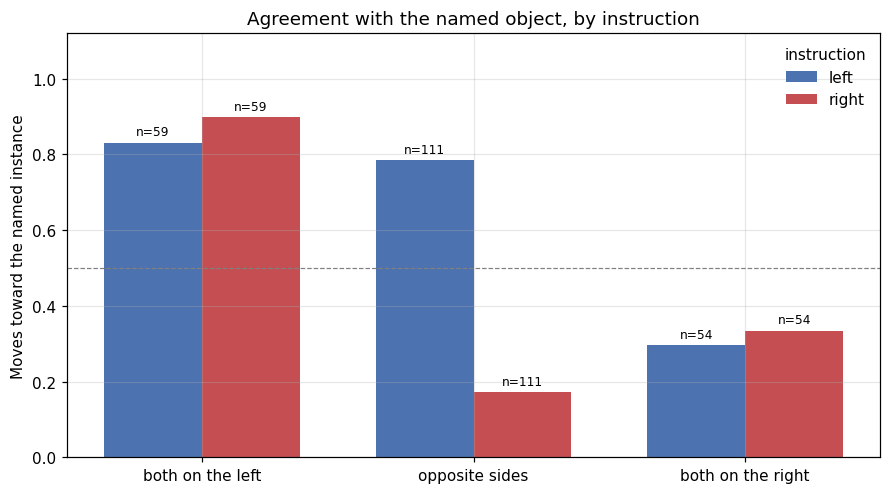

In [43]:
if built.empty:
    print('no constructed predictions; run Notebooks 03 and 05 first')
else:
    absolute = absolute_congruence(built, lateral_sign=IMAGE_X_TO_LATERAL_SIGN,
                                   min_magnitude=BIN_WIDTH)
    fig, ax = plt.subplots(figsize=(8.2, 4.6))
    x = np.arange(len(CONFIG_ORDER))
    width = 0.36
    for offset, role in ((-width / 2, 'a'), (width / 2, 'b')):
        heights, ns = [], []
        for name in CONFIG_ORDER:
            entry = absolute.get('by_configuration', {}).get(name, {})
            heights.append(entry.get(f'agreement_{role}', np.nan))
            ns.append(entry.get('n', 0))
        bars = ax.bar(x + offset, heights, width, color=ROLE_COLOURS[role],
                      label=ROLE_LABELS[role])
        for i, (height, n) in enumerate(zip(heights, ns)):
            if np.isfinite(height):
                ax.text(x[i] + offset, height + 0.02, f'n={n}',
                        ha='center', fontsize=8)
    ax.axhline(0.5, color='grey', ls='--', lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([CONFIG_LABELS[c] for c in CONFIG_ORDER])
    ax.set_ylim(0, 1.12)
    ax.set_ylabel('Moves toward the named instance')
    ax.set_title('Agreement with the named object, by instruction')
    ax.legend(frameon=False, title='instruction')
    fig.tight_layout()
    save(fig, '02_target_agreement.png')
    plt.show()


## 6. Signed lateral action by instruction and arrangement

The quantity behind the bars: each scene contributes two lateral values, one for
`left` and one for `right`. Zero is no lateral motion. The band is one action
bin.

A grounded model places both points on the side the objects occupy. A
word-to-direction mapping places `left` and `right` on opposite sides of zero in
every column. An image-left prior places both instructions on one side of zero
in every column.


wrote /content/drive/MyDrive/openvla_cache/v2/results_figs/03_signed_actions.png


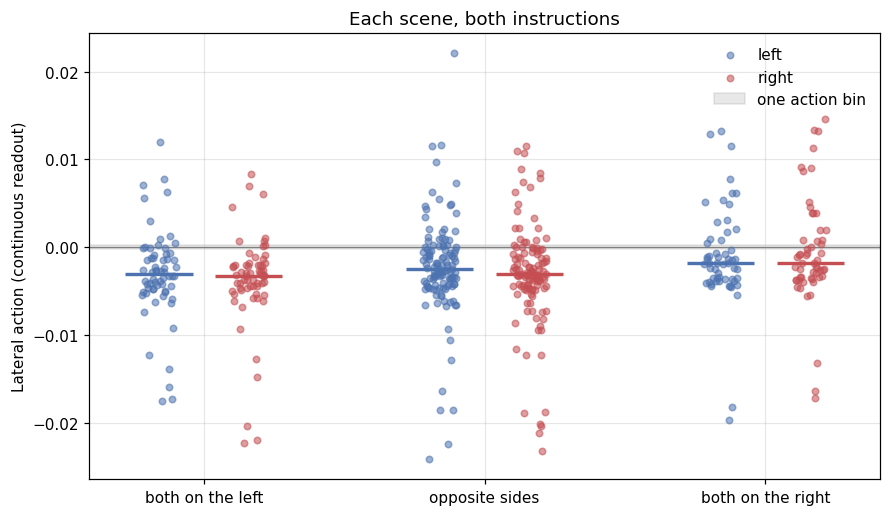

                     left     right
configuration                      
same_side_left  -0.003067 -0.003231
opposite        -0.002461 -0.003092
same_side_right -0.001804 -0.001785


In [44]:
pairs = baseline_pairs(built)
if pairs.empty:
    print('no baseline pairs on the constructed set')
else:
    fig, ax = plt.subplots(figsize=(8.2, 4.8))
    rng = np.random.default_rng(0)
    for i, name in enumerate(CONFIG_ORDER):
        group = pairs[pairs['configuration'] == name]
        for role, x0 in (('a', i - 0.16), ('b', i + 0.16)):
            values = group[role].to_numpy()
            jitter = rng.uniform(-0.06, 0.06, size=len(values))
            ax.scatter(np.full(len(values), x0) + jitter, values, s=18, alpha=0.55,
                       color=ROLE_COLOURS[role], zorder=3,
                       label=ROLE_LABELS[role] if i == 0 else None)
            if len(values):
                ax.hlines(float(np.median(values)), x0 - 0.12, x0 + 0.12,
                          color=ROLE_COLOURS[role], lw=2.2, zorder=4)
    ax.axhline(0, color='grey', lw=0.8)
    ax.axhspan(-BIN_WIDTH, BIN_WIDTH, color='grey', alpha=0.18, zorder=0,
               label='one action bin')
    ax.set_xticks(range(len(CONFIG_ORDER)))
    ax.set_xticklabels([CONFIG_LABELS[c] for c in CONFIG_ORDER])
    ax.set_ylabel('Lateral action (continuous readout)')
    ax.set_title('Each scene, both instructions')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, frameon=False)
    fig.tight_layout()
    save(fig, '03_signed_actions.png')
    plt.show()
    print(pairs.groupby('configuration')[['a', 'b']].median().reindex(CONFIG_ORDER)
          .rename(columns=ROLE_LABELS).to_string())


## 7. Instrument check: response to mirroring

Each point is one scene: its lateral value on the original image against its
value on the horizontally flipped image, with the instruction held fixed. A model
that reverses lateral output under reflection sits on the falling anti-diagonal.
A model that ignores the image sits on the rising diagonal. A biased policy that
still reads the image can sit off both lines: the output changes without changing
sign.

The left panel uses the term-stripped instruction and is the cleaner reading,
since it isolates object grounding from any influence of the spatial word. This
figure is the gate for whether the visual channel is live, not evidence of
spatial-language grounding.

The constructed arrangements are separate series. Reflecting an `opposite`
arrangement maps the layout onto itself, so those points sit near the origin
however the model behaves; the same-side series is where the reflection
genuinely moves the scene, and it is the one to read.


wrote /content/drive/MyDrive/openvla_cache/v2/results_figs/04_instrument_mirror.png


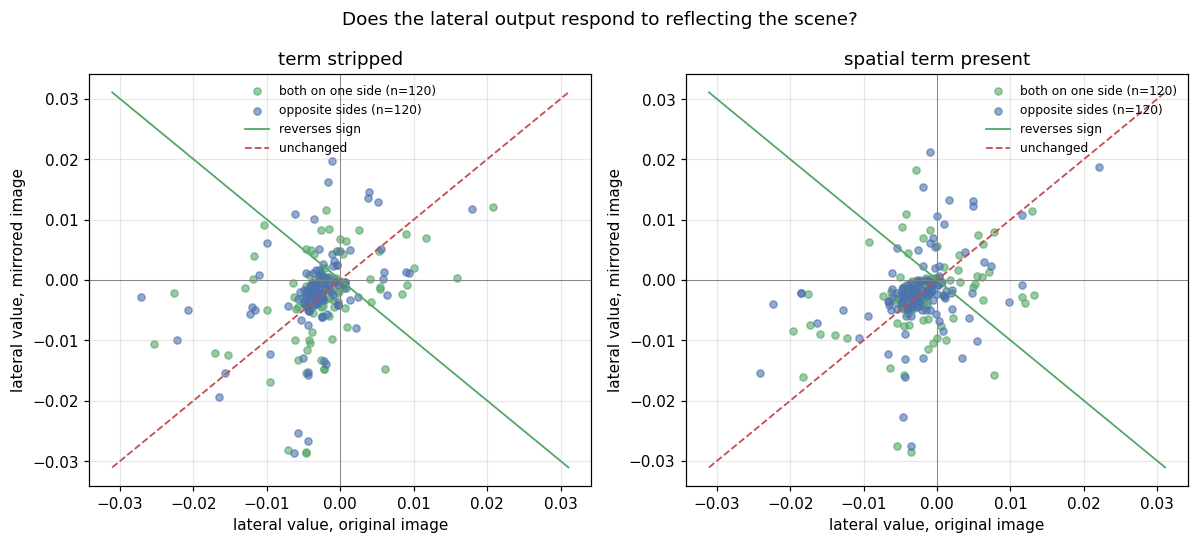

In [45]:
def mirror_pairs(frame, plain, flipped, role):
    """Per-scene lateral value on the original and mirrored image."""
    out = {}
    for label, condition in (('plain', plain), ('mirror', flipped)):
        sub = frame[(frame['condition'] == condition) & (frame['role'] == role)].copy()
        if sub.empty:
            return pd.DataFrame(columns=['plain', 'mirror'])
        sub['value'] = axis_value(sub)
        out[label] = sub.groupby('scene_id')['value'].mean()
    return pd.DataFrame(out).dropna()

lateral = usable[usable['axis_index'] == AXIS_INDEX['lateral']]
panels = [('term stripped', 'neutral', 'mirror_neutral', 'n'),
          ('spatial term present', 'baseline', 'mirror', 'a')]

same_side = lateral['configuration'].astype(str).str.startswith('same_side')
series = [
    ('both on one side', lateral[same_side], COLOURS['same_side_left']),
    ('opposite sides', lateral[~same_side], COLOURS['opposite']),
]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (title, plain, flipped, role) in zip(axes, panels):
    drawn = False
    for label, frame, colour in series:
        points = mirror_pairs(frame, plain, flipped, role)
        if points.empty:
            continue
        ax.scatter(points['plain'], points['mirror'], s=22, alpha=0.6,
                   color=colour, label=f'{label} (n={len(points)})')
        drawn = True
    if not drawn:
        ax.text(0.5, 0.5, 'no paired mirror predictions', ha='center', va='center')
        ax.axis('off')
        continue
    span = max(abs(np.array(ax.get_xlim())).max(), abs(np.array(ax.get_ylim())).max())
    ax.plot([-span, span], [span, -span], color='#55A868', lw=1.2,
            label='reverses sign')
    ax.plot([-span, span], [-span, span], color='#C44E52', ls='--', lw=1.2,
            label='unchanged')
    ax.axhline(0, color='grey', lw=0.6)
    ax.axvline(0, color='grey', lw=0.6)
    ax.set_xlabel('lateral value, original image')
    ax.set_ylabel('lateral value, mirrored image')
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=8)

fig.suptitle('Does the lateral output respond to reflecting the scene?')
fig.tight_layout()
save(fig, '04_instrument_mirror.png')
plt.show()


## 8. Controls: does the instruction contrast depend on the scene?

Each point is one scene under a given image: the lateral action for `left`
against the lateral action for `right`. Points on the rising diagonal are
same-signed (both instructions take the same direction). Points on the falling
diagonal are a word-to-direction mapping. The band around zero is one action bin.

The left panel is the scene the instruction describes. The right panel is a
different scene, so any contrast that survives there cannot come from the named
referent. Colour is the recorded arrangement of the constructed stimulus, not of
the substituted image.


wrote /content/drive/MyDrive/openvla_cache/v2/results_figs/05_instruction_scatter.png


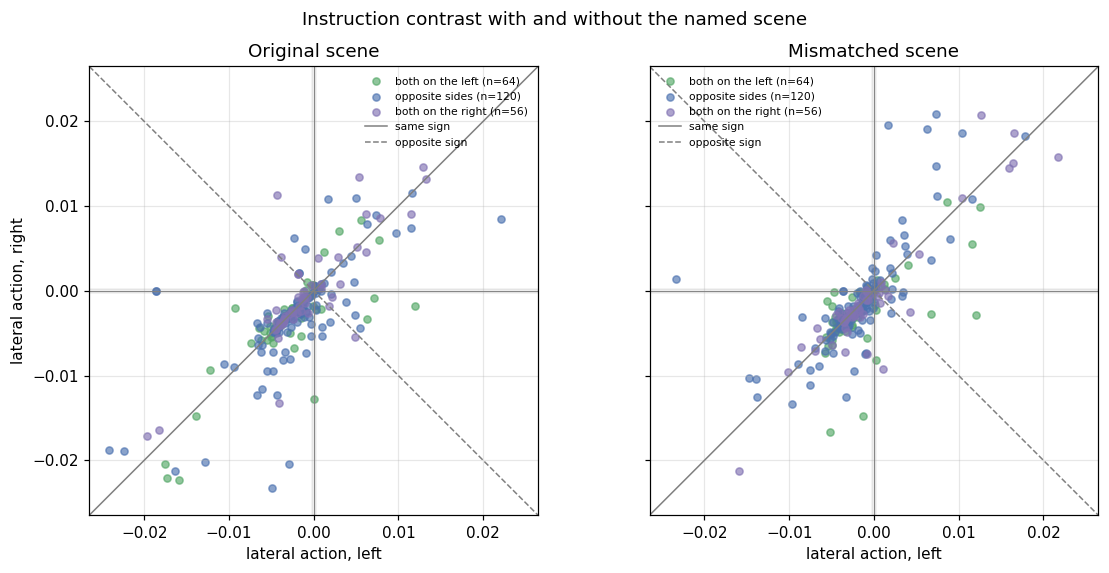

swapped/baseline mean |difference| ratio = 0.88


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2), sharex=True, sharey=True)
for ax, condition, title in (
    (axes[0], 'baseline', 'Original scene'),
    (axes[1], 'swapped_scene', 'Mismatched scene'),
):
    pairs = baseline_pairs(usable, condition=condition)
    drawn = False
    for name in CONFIG_ORDER:
        group = pairs[pairs['configuration'] == name]
        if group.empty:
            continue
        ax.scatter(group['a'], group['b'], s=22, alpha=0.65,
                   color=COLOURS[name],
                   label=f'{CONFIG_LABELS[name]} (n={len(group)})')
        drawn = True
    if not drawn:
        ax.text(0.5, 0.5, 'no paired predictions', ha='center', va='center')
        ax.axis('off')
        continue
    span = max(abs(np.array(ax.get_xlim())).max(),
               abs(np.array(ax.get_ylim())).max(), BIN_WIDTH * 3)
    ax.plot([-span, span], [-span, span], color='grey', lw=1.0,
            label='same sign')
    ax.plot([-span, span], [span, -span], color='grey', ls='--', lw=1.0,
            label='opposite sign')
    ax.axhspan(-BIN_WIDTH, BIN_WIDTH, color='grey', alpha=0.12)
    ax.axvspan(-BIN_WIDTH, BIN_WIDTH, color='grey', alpha=0.12)
    ax.axhline(0, color='grey', lw=0.6)
    ax.axvline(0, color='grey', lw=0.6)
    ax.set_xlim(-span, span)
    ax.set_ylim(-span, span)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('lateral action, left')
    ax.set_title(title)
    ax.legend(frameon=False, fontsize=7)
axes[0].set_ylabel('lateral action, right')
fig.suptitle('Instruction contrast with and without the named scene')
fig.tight_layout()
save(fig, '05_instruction_scatter.png')
plt.show()

result = lexical_check(usable)
if np.isfinite(result['ratio']):
    print(f'swapped/baseline mean |difference| ratio = {result["ratio"]:.2f}')


## 9. Measurement resolution

What the quantisation was hiding. The same paired differences are shown twice:
as the argmax action the model would execute, and as the continuous expected-bin
value. The shaded band is one action bin, the width below which two predictions
cannot differ in the executable action.


wrote /content/drive/MyDrive/openvla_cache/v2/results_figs/06_resolution.png


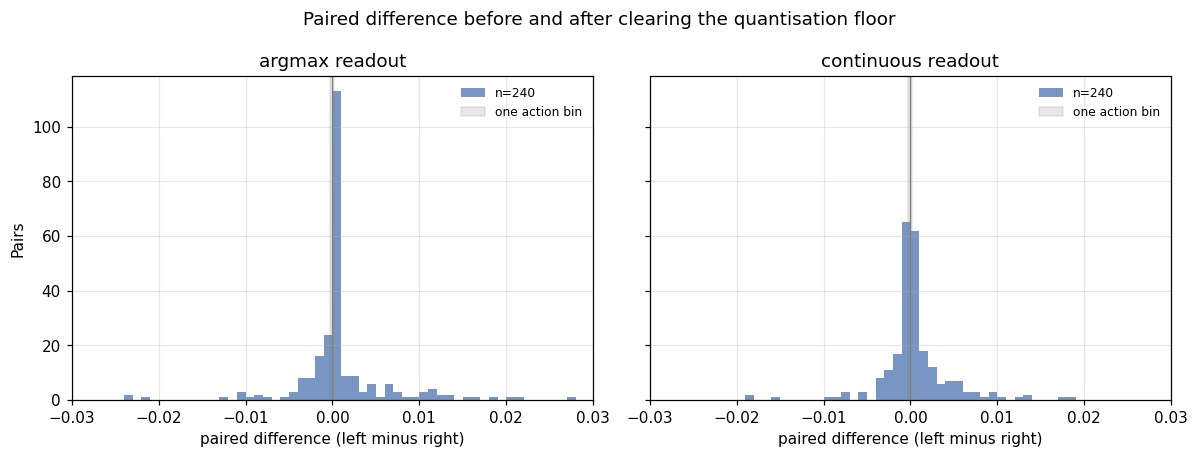

   readout   n  frac_exact_zero  frac_below_bin  n_distinct
    argmax 240         0.408333        0.450000         123
continuous 240         0.000000        0.279167         231


In [47]:
series = {}
for readout, flag in (('argmax', False), ('continuous', True)):
    diffs = paired_difference(usable, continuous=flag)['diff'].to_numpy()
    if diffs.size:
        series[readout] = diffs

widest = max((np.abs(d).max() for d in series.values()), default=BIN_WIDTH)
limit = max(3 * BIN_WIDTH, 1.1 * widest)
edges = np.linspace(-limit, limit, 61)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True, sharex=True)
rows = []
for ax, readout in zip(axes, ('argmax', 'continuous')):
    diffs = series.get(readout)
    if diffs is None:
        ax.text(0.5, 0.5, 'no paired differences', ha='center', va='center')
        ax.axis('off')
        continue
    ax.hist(diffs, bins=edges, alpha=0.75, color=COLOURS['constructed'],
            label=f'n={diffs.size}')
    rows.append({'readout': readout, **resolution_report(diffs, BIN_WIDTH)})
    ax.axvspan(-BIN_WIDTH, BIN_WIDTH, color='grey', alpha=0.18,
               label='one action bin')
    ax.axvline(0, color='grey', lw=0.8)
    ax.set_xlim(-limit, limit)
    ax.set_xlabel('paired difference (left minus right)')
    ax.set_title(f'{readout} readout')
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel('Pairs')
fig.suptitle('Paired difference before and after clearing the quantisation floor')
fig.tight_layout()
save(fig, '06_resolution.png')
plt.show()

resolution = pd.DataFrame(rows)
if not resolution.empty:
    print(resolution[['readout', 'n', 'frac_exact_zero',
                      'frac_below_bin', 'n_distinct']].to_string(index=False))


## 10. Inventory

What was actually collected. Unequal counts per condition are expected: a
condition is skipped when its precondition fails, for example a term-stripped
condition where no clean removal exists. Every figure above is conditional on
these counts.


wrote /content/drive/MyDrive/openvla_cache/v2/results_figs/07_inventory.png


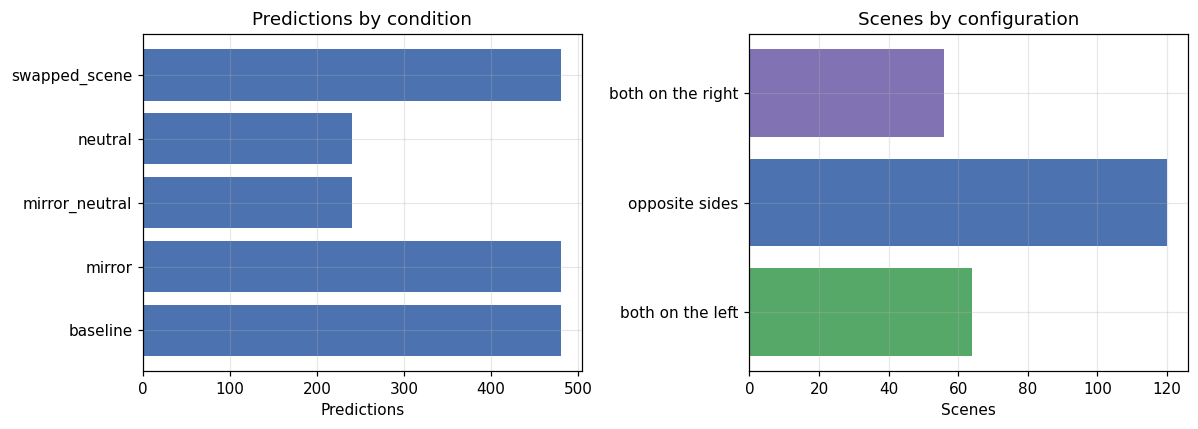

condition
baseline          480
mirror            480
mirror_neutral    240
neutral           240
swapped_scene     480


In [48]:
inventory = usable['condition'].value_counts().sort_index()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].barh(inventory.index.astype(str), inventory.to_numpy(),
             color=COLOURS['constructed'])
axes[0].set_xlabel('Predictions')
axes[0].set_ylabel('')
axes[0].set_title('Predictions by condition')

if not built.empty:
    counts = built.groupby('configuration')['scene_id'].nunique()
    counts = counts.reindex(CONFIG_ORDER).dropna()
    axes[1].barh([CONFIG_LABELS[c] for c in counts.index], counts.to_numpy(),
                 color=[COLOURS.get(c, '#7F7F7F') for c in counts.index])
    axes[1].set_xlabel('Scenes')
    axes[1].set_title('Scenes by configuration')
else:
    axes[1].text(0.5, 0.5, 'No constructed scenes', ha='center', va='center')
    axes[1].axis('off')

fig.tight_layout()
save(fig, '07_inventory.png')
plt.show()
print(inventory.to_string())


## 11. Constructed scene gallery

Examples of the stimuli, with the recorded geometry drawn on the objects: the
source instance, the pasted duplicate, and the detected start position. Included
so a reader can see what the model was shown and judge whether the composited
instance is plausible, which no summary statistic conveys.


wrote /content/drive/MyDrive/openvla_cache/v2/results_figs/08_constructed_gallery.png


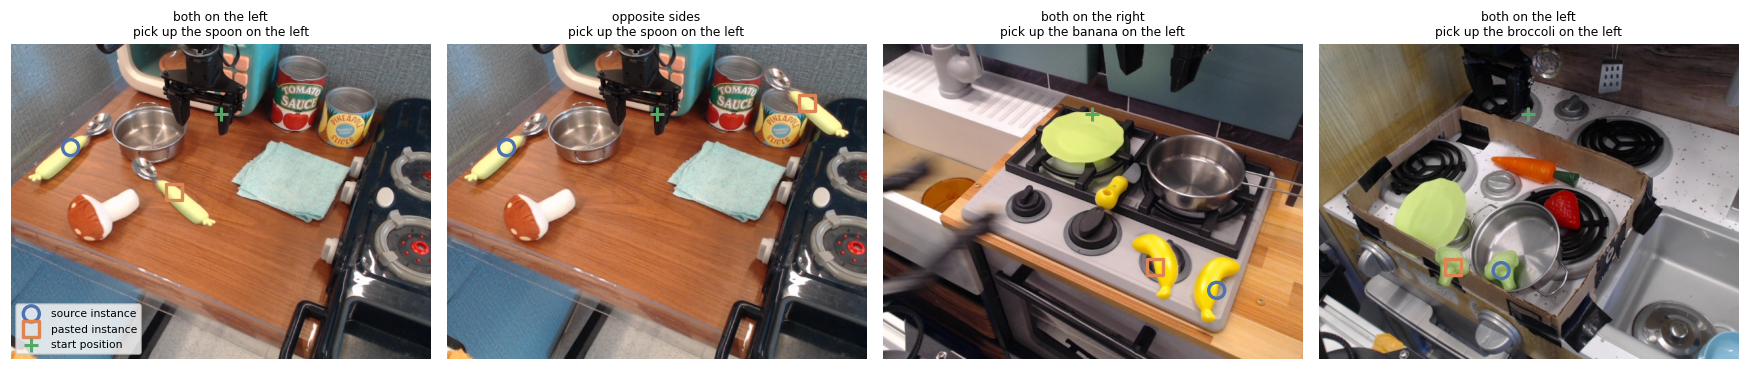

In [49]:
from PIL import Image

GALLERY_N = 4
scenes = evaluation_scenes(CONSTRUCTED_DIR)
if not scenes:
    print('no frozen evaluation set; screen and freeze in Notebook 03 first')
else:
    chosen, seen = [], set()
    for name in CONFIG_ORDER:
        for scene in scenes:
            if scene['configuration'] == name and name not in seen:
                chosen.append(scene)
                seen.add(name)
                break
    chosen += [s for s in scenes if s not in chosen][:max(0, GALLERY_N - len(chosen))]
    chosen = chosen[:GALLERY_N]

    if chosen:
        fig, axes = plt.subplots(1, len(chosen), figsize=(4 * len(chosen), 4.6))
        axes = [axes] if len(chosen) == 1 else list(axes)
        for ax, scene in zip(axes, chosen):
            image = Image.open(os.path.join(CONSTRUCTED_DIR, scene['image_path']))
            ax.imshow(image)
            y_source = float(scene['y_source'])
            y_pasted = y_source + float(scene.get('y_shift_px') or 0)
            x_grip, y_grip = gripper_image_xy(scene, image.height)
            ax.scatter([float(scene['x_source'])], [y_source], marker='o', s=110,
                       facecolors='none', edgecolors='#4C72B0', linewidths=2.2,
                       label='source instance')
            ax.scatter([float(scene['x_pasted'])], [y_pasted], marker='s', s=110,
                       facecolors='none', edgecolors='#DD8452', linewidths=2.2,
                       label='pasted instance')
            ax.scatter([x_grip], [y_grip], marker='+', s=90, color='#55A868',
                       linewidths=2.0, label='start position')
            ax.set_title(f"{CONFIG_LABELS.get(scene['configuration'], scene['configuration'])}"
                         f"\n{scene['instr_a']}", fontsize=8)
            ax.set_xlim(0, image.width)
            ax.set_ylim(image.height, 0)
            ax.axis('off')
        axes[0].legend(loc='lower left', fontsize=7)
        fig.tight_layout()
        save(fig, '08_constructed_gallery.png')
        plt.show()


## 12. Unaltered Bridge scenes

Held back. Those frames remain in the prediction log for a later validation
analysis after the review in Notebook 04. No figure is written for them here.


In [50]:
print(f'{n_bridge} unaltered Bridge predictions are in the log and are not '
      'plotted here')


8276 unaltered Bridge predictions are in the log and are not plotted here


## 13. Figure index

All PNGs written in this session under `results_figs/`.


In [52]:
EXPECTED = (
    '01_predicted_directions.png',
    '02_target_agreement.png',
    '03_signed_actions.png',
    '04_instrument_mirror.png',
    '05_instruction_scatter.png',
    '06_resolution.png',
    '07_inventory.png',
    '08_constructed_gallery.png',
)
written = sorted(f for f in os.listdir(FIGS_DIR) if f.endswith('.png'))
print(f'{len(written)} PNG files in {FIGS_DIR}')
for name in EXPECTED:
    print(' ', name, 'ok' if name in written else 'missing')
leftover = [name for name in written if name not in EXPECTED]
if leftover:
    print('leftover from earlier sessions:')
    for name in leftover:
        print(' ', name)


16 PNG files in /content/drive/MyDrive/openvla_cache/v2/results_figs
  01_predicted_directions.png ok
  02_target_agreement.png ok
  03_signed_actions.png ok
  04_instrument_mirror.png ok
  05_instruction_scatter.png ok
  06_resolution.png ok
  07_inventory.png ok
  08_constructed_gallery.png ok
leftover from earlier sessions:
  01_inventory.png
  02_instrument_mirror.png
  03_resolution.png
  04_same_side_contrast.png
  04b_predicted_directions.png
  05_controls.png
  06_bridge_strata.png
  07_constructed_gallery.png
